# Improved MTTL Notebook  
**Aggression + Offensive Language Detection for Hindi-English code-mixed tweets**

This notebook extends the paper-faithful MTTL baseline (IndoNLP 2025) with four targeted improvements. It is **fully self-contained** — it does not depend on the original `reimplementation.ipynb` and runs end-to-end from scratch.

## Improvements over the baseline

1. **Dynamic task weighting** (replaces fixed `w_a`)  
   Implements Kendall et al. (2018) **homoscedastic uncertainty weighting**. Two learnable log-variance parameters `s_a` and `s_o` automatically balance the aggression and offense losses during training. The combined loss becomes  
   `L = exp(-s_a) · L_a + s_a + exp(-s_o) · L_o + s_o`  
   The model learns to give noisier tasks lower effective weight, removing the need to manually tune `w_a`.

2. **Focal loss for class imbalance** (replaces weighted cross-entropy)  
   Alpha-balanced multi-class **focal loss** with γ = 2.0. The existing dataset-level class weights are reused as α, and the `(1 − p_t)^γ` factor concentrates gradients on hard examples. This is more effective than plain weighted CE for the minority OAG and OFF classes.

3. **Hierarchical task prediction** (offense → aggression)  
   Reflects the dependency that most offensive tweets are aggressive. Offense is predicted first; its **soft probabilities** are then concatenated with the shared CLS representation and fed to the aggression head. Using soft probabilities (not hard labels) means train and inference behave identically — no teacher-forcing mismatch.  
   This improvement is **toggleable** via `CFG.use_hierarchy`. Set it to `False` if it hurts results on your split — improvements 1, 2, and 4 will still apply.

4. **Error analysis and explainability**  
   - Confusion matrices for both tasks (heatmaps)  
   - Per-class precision / recall / F1 breakdown  
   - **Joint** OFF/NOT × OAG/CAG/NAG cross-task confusion  
   - Top misclassified examples (highest-confidence errors)  
   - **Gradient-based token saliency maps** (gradient × input on word embeddings) with HTML visualization

## Expected dataset layout
```
./original_split/
    train.csv
    validation.csv
    test.csv
```
Each CSV must have columns: `tweet`, `aggression`, `offense`. Labels can be either the paper's strings (`OAG/CAG/NAG`, `OFF/NOT`) or pre-encoded integers — the notebook handles both.

## 1. Clone repo (skip if data is already local)

In [ ]:
# Clone the repository that contains the original_split/ folder.
# If you already have the dataset locally, comment these two lines out.
!git clone https://github.com/opius005/Aggression-and-Offensive-Language-Detection.git
%cd Aggression-and-Offensive-Language-Detection

## 2. Install dependencies

In [ ]:
!pip install -q transformers datasets accelerate scikit-learn pandas numpy matplotlib seaborn tqdm

In [1]:
import torch
print("torch:", torch.__version__)
print("compiled CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

torch: 2.11.0+cu126
compiled CUDA: 12.6
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 3. Imports and seed

In [1]:
import os
import re
import math
import json
import random
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from datasets import Dataset, DatasetDict
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoConfig,
    DataCollatorWithPadding,
    get_scheduler,
)
from transformers.utils import ModelOutput

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 46
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

c:\Users\rafay\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


## 4. Configuration

The four improvement toggles are at the bottom of the config. The defaults enable all four improvements. To disable improvement 3 (hierarchy), flip a single flag — the rest of the notebook adapts automatically.

In [2]:
class CFG:
    # Model
    model_name = "l3cube-pune/hing-roberta"
    max_length = 128

    # Training
    batch_size = 4
    learning_rate = 1e-5
    weight_decay = 0.01
    num_epochs = 6
    warmup_ratio = 0.1
    dropout_prob = 0.15

    # Architecture
    offense_n_hidden = 3   # paper finding: task-specific layers help offense
    hidden_size = 768

    # ----- Improvement toggles -----
    # Improvement 1: dynamic uncertainty-based task weighting
    use_dynamic_weighting = True
    # Fallback fixed weight, only used if use_dynamic_weighting = False
    w_a = 0.4

    # Improvement 2: loss function
    loss_type = "ce"        # "focal" or "ce"
    focal_gamma = 2.0          # focal loss focusing parameter

    # Improvement 3: hierarchical offense -> aggression prediction
    # Set to False to disable hierarchy and recover the original parallel structure.
    use_hierarchy = True

    # Data paths
    train_path = "./original_split/train.csv"
    val_path   = "./original_split/validation.csv"
    test_path  = "./original_split/test.csv"

    # Saving
    output_dir = "./mttl_improved_outputs"

os.makedirs(CFG.output_dir, exist_ok=True)
print("Improvements enabled:")
print(f"  1. Dynamic task weighting : {CFG.use_dynamic_weighting}")
print(f"  2. Loss function          : {CFG.loss_type} (gamma={CFG.focal_gamma})")
print(f"  3. Hierarchical prediction: {CFG.use_hierarchy}")
print(f"  4. Error analysis         : enabled (runs after training)")

Improvements enabled:
  1. Dynamic task weighting : True
  2. Loss function          : ce (gamma=2.0)
  3. Hierarchical prediction: True
  4. Error analysis         : enabled (runs after training)


## 5. Load data

In [3]:
train_df = pd.read_csv(CFG.train_path, encoding="utf-8")
val_df   = pd.read_csv(CFG.val_path, encoding="utf-8")
test_df  = pd.read_csv(CFG.test_path, encoding="utf-8")

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)
train_df.head()

Train: (6624, 5)
Val  : (828, 5)
Test : (829, 5)


,id,aggression,offense,codemixed,tweet
0,872,0,0,0,Deprived of justice for decades is acceptable....
1,3271,1,1,1,યોગ્ય ન્યાય મળવો જોઈએ
2,2534,2,1,0,Every Stupid Idea starts with these same lines...
3,20,2,1,1,"All undertrials, criminals and convicts have d..."
4,7729,0,0,1,"Islamic phobia and Nehru, Gandhi phobia से कब ..."


## 6. Label mapping

If labels are strings (`OAG/CAG/NAG`, `OFF/NOT`), map them. If already integers, leave them alone.

In [4]:
AGG_MAP = {"OAG": 0, "CAG": 1, "NAG": 2}
OFF_MAP = {"OFF": 0, "NOT": 1}

INV_AGG = {v: k for k, v in AGG_MAP.items()}
INV_OFF = {v: k for k, v in OFF_MAP.items()}

def maybe_map_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if df["aggression"].dtype == object:
        unique_vals = set(df["aggression"].dropna().astype(str).unique())
        if unique_vals.issubset(set(AGG_MAP.keys())):
            df["aggression"] = df["aggression"].map(AGG_MAP)
    if df["offense"].dtype == object:
        unique_vals = set(df["offense"].dropna().astype(str).unique())
        if unique_vals.issubset(set(OFF_MAP.keys())):
            df["offense"] = df["offense"].map(OFF_MAP)
    df["aggression"] = df["aggression"].astype(int)
    df["offense"] = df["offense"].astype(int)
    return df

train_df = maybe_map_labels(train_df)
val_df   = maybe_map_labels(val_df)
test_df  = maybe_map_labels(test_df)

print("Aggression distribution (train):")
print(train_df["aggression"].value_counts().sort_index().rename(INV_AGG))
print("\nOffense distribution (train):")
print(train_df["offense"].value_counts().sort_index().rename(INV_OFF))

Aggression distribution (train):
aggression
OAG    3119
CAG    2019
NAG    1486
Name: count, dtype: int64

Offense distribution (train):
offense
OFF    4638
NOT    1986
Name: count, dtype: int64


## 7. Preprocessing

Mask user mentions to `@user` (paper-faithful).

In [5]:
MENTION_RE = re.compile(r'@[A-Za-z0-9_]+')

def normalize_tweet(text: str) -> str:
    text = str(text)
    text = MENTION_RE.sub("@user", text)
    return text.strip()

for df in [train_df, val_df, test_df]:
    df["tweet"] = df["tweet"].astype(str).apply(normalize_tweet)

train_df["tweet"].head()

0    Deprived of justice for decades is acceptable....
1                                યોગ્ય ન્યાય મળવો જોઈએ
2    Every Stupid Idea starts with these same lines...
3    All undertrials, criminals and convicts have d...
4    Islamic phobia and Nehru, Gandhi phobia से कब ...
Name: tweet, dtype: object

## 8. Compute dataset-level class weights

Used as α in focal loss (improvement 2). Computed once from the training set, not per batch.

In [6]:
def compute_class_weights(labels: pd.Series, num_classes: int) -> torch.Tensor:
    counts = labels.value_counts().sort_index()
    full_counts = np.zeros(num_classes, dtype=np.float32)
    for cls_idx, count in counts.items():
        full_counts[int(cls_idx)] = float(count)
    total = full_counts.sum()
    weights = total / (num_classes * np.clip(full_counts, a_min=1.0, a_max=None))
    return torch.tensor(weights, dtype=torch.float)

agg_weights = compute_class_weights(train_df["aggression"], num_classes=3)
off_weights = compute_class_weights(train_df["offense"], num_classes=2)

print("Aggression class weights (OAG, CAG, NAG):", agg_weights.tolist())
print("Offense class weights    (OFF, NOT)    :", off_weights.tolist())

Aggression class weights (OAG, CAG, NAG): [0.707919180393219, 1.0936106443405151, 1.4858680963516235]
Offense class weights    (OFF, NOT)    : [0.7141008973121643, 1.6676737070083618]


## 9. Build Hugging Face datasets

In [7]:
train_ds = Dataset.from_pandas(train_df[["tweet", "aggression", "offense"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["tweet", "aggression", "offense"]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["tweet", "aggression", "offense"]], preserve_index=False)

dataset = DatasetDict({"train": train_ds, "val": val_ds, "test": test_ds})
dataset

DatasetDict({
    train: Dataset({
        features: ['tweet', 'aggression', 'offense'],
        num_rows: 6624
    })
    val: Dataset({
        features: ['tweet', 'aggression', 'offense'],
        num_rows: 828
    })
    test: Dataset({
        features: ['tweet', 'aggression', 'offense'],
        num_rows: 829
    })
})

## 10. Tokenization

In [8]:
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["tweet"],
        truncation=True,
        max_length=CFG.max_length,
        padding=False,
    )

tokenized = dataset.map(tokenize_batch, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "aggression", "offense"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
tokenized

Map: 100%|██████████| 829/829 [00:00<00:00, 26266.48 examples/s]


DatasetDict({
    train: Dataset({
        features: ['tweet', 'aggression', 'offense', 'input_ids', 'attention_mask'],
        num_rows: 6624
    })
    val: Dataset({
        features: ['tweet', 'aggression', 'offense', 'input_ids', 'attention_mask'],
        num_rows: 828
    })
    test: Dataset({
        features: ['tweet', 'aggression', 'offense', 'input_ids', 'attention_mask'],
        num_rows: 829
    })
})

## 11. Dataloaders

In [9]:
train_loader = DataLoader(
    tokenized["train"], batch_size=CFG.batch_size, shuffle=True, collate_fn=data_collator,
)
val_loader = DataLoader(
    tokenized["val"], batch_size=CFG.batch_size, shuffle=False, collate_fn=data_collator,
)
test_loader = DataLoader(
    tokenized["test"], batch_size=CFG.batch_size, shuffle=False, collate_fn=data_collator,
)
len(train_loader), len(val_loader), len(test_loader)

(1656, 207, 208)

## 12. Improvement 2 — Focal Loss

Alpha-balanced multi-class focal loss:
$$\mathcal{L}_{\text{focal}}(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

- `α` is the per-class weight tensor (the dataset-level weights computed above).  
- `γ = 2.0` (default) down-weights well-classified examples by `(1 - p_t)^γ`.  
- When `γ = 0`, this reduces to weighted cross-entropy.

In [10]:
class FocalLoss(nn.Module):
    """Multi-class alpha-balanced focal loss.

    Args:
        alpha: tensor of shape [num_classes] with per-class weights, or None.
        gamma: focusing parameter (>= 0). gamma=0 reduces to weighted CE.
        reduction: 'mean' | 'sum' | 'none'.
    """
    def __init__(self, alpha: Optional[torch.Tensor] = None, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is None:
            self.register_buffer("alpha", None)
        else:
            self.register_buffer("alpha", alpha.float())

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits: [B, C], targets: [B] (long)
        log_probs = F.log_softmax(logits, dim=-1)               # [B, C]
        log_p_t = log_probs.gather(dim=-1, index=targets.unsqueeze(-1)).squeeze(-1)  # [B]
        p_t = log_p_t.exp().clamp(min=1e-8, max=1.0 - 1e-8)     # [B]
        focal_weight = (1.0 - p_t).pow(self.gamma)              # [B]

        if self.alpha is not None:
            alpha_t = self.alpha[targets]                       # [B]
            loss = -alpha_t * focal_weight * log_p_t
        else:
            loss = -focal_weight * log_p_t

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss


def make_loss_fn(loss_type: str, alpha: torch.Tensor, gamma: float) -> nn.Module:
    if loss_type == "focal":
        return FocalLoss(alpha=alpha, gamma=gamma, reduction="mean")
    if loss_type == "ce":
        return nn.CrossEntropyLoss(weight=alpha)
    raise ValueError(f"Unknown loss_type: {loss_type}")

## 13. Improvement 1 — Dynamic Uncertainty Weighting

Following Kendall, Gal & Cipolla (2018). Each task gets a learnable `log_var` (= `log σ²`). The combined loss is
$$\mathcal{L} = \sum_i \Big( e^{-s_i} \, \mathcal{L}_i + s_i \Big)$$
where `s_i = log σ_i²`. Tasks with higher noise (`σ_i` large) get smaller weight automatically.

We track these weights per epoch and plot them later so you can see the dynamic balancing in action.

In [11]:
class UncertaintyWeighting(nn.Module):
    """Learnable homoscedastic-uncertainty task balancing."""

    def __init__(self, num_tasks: int = 2, init: float = 0.0):
        super().__init__()
        # log_vars[i] = log(sigma_i^2). Initialized to 0 -> sigma=1 -> equal weights.
        self.log_vars = nn.Parameter(torch.full((num_tasks,), float(init)))

    def forward(self, losses: List[torch.Tensor]) -> torch.Tensor:
        """Combine per-task losses into a single scalar."""
        total = 0.0
        for i, loss in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            total = total + precision * loss + self.log_vars[i]
        return total

    @torch.no_grad()
    def effective_weights(self) -> List[float]:
        """Return exp(-log_var) for each task, useful for monitoring."""
        return [float(torch.exp(-lv).item()) for lv in self.log_vars]

    @torch.no_grad()
    def log_vars_list(self) -> List[float]:
        return [float(lv.item()) for lv in self.log_vars]

## 14. Model output container

In [12]:
@dataclass
class MultiTaskOutput(ModelOutput):
    loss: Optional[torch.FloatTensor] = None
    loss_a: Optional[torch.FloatTensor] = None
    loss_o: Optional[torch.FloatTensor] = None
    logits_a: Optional[torch.FloatTensor] = None
    logits_o: Optional[torch.FloatTensor] = None
    hidden_states: Optional[Tuple[torch.FloatTensor, ...]] = None
    attentions: Optional[Tuple[torch.FloatTensor, ...]] = None

## 15. Model — incorporates Improvements 1, 2, 3

- **Shared encoder** (HingRoBERTa) feeds both tasks.
- **Offense head**: shared representation + task-specific hidden layers (paper finding kept).
- **Aggression head**:
    - If `use_hierarchy=True`: takes `[CLS] ⊕ softmax(offense_logits)` as input — soft conditioning on offense.
    - If `use_hierarchy=False`: takes shared `[CLS]` only (parallel, paper-faithful).
- **Loss combination**:
    - If `use_dynamic_weighting=True`: handled outside the model (so the optimizer sees the `log_vars` parameters cleanly). The model returns per-task losses.
    - Otherwise: uses the fixed `w_a` mixture as a fallback.
- The forward pass also accepts `inputs_embeds` so we can compute gradient saliency in improvement 4.

In [13]:
class ClassificationHead(nn.Module):
    """Standard CLS-pooled head: dense -> tanh -> dropout -> out_proj."""
    def __init__(self, input_dim: int, num_labels: int, dropout_prob: float, hidden_dim: Optional[int] = None):
        super().__init__()
        hidden_dim = hidden_dim or input_dim
        self.dropout = nn.Dropout(dropout_prob)
        self.dense = nn.Linear(input_dim, hidden_dim)
        self.out_proj = nn.Linear(hidden_dim, num_labels)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, input_dim] (already pooled)
        x = self.dropout(x)
        x = torch.tanh(self.dense(x))
        x = self.dropout(x)
        return self.out_proj(x)


class TaskSpecificHiddenLayers(nn.Module):
    def __init__(self, n_hidden: int, hidden_size: int, dropout_prob: float):
        super().__init__()
        layers = []
        for _ in range(n_hidden):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.LayerNorm(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class MTTLModel(nn.Module):
    def __init__(
        self,
        model_name: str,
        n_a_labels: int = 3,
        n_o_labels: int = 2,
        offense_n_hidden: int = 3,
        dropout_prob: float = 0.15,
        loss_fn_a: Optional[nn.Module] = None,
        loss_fn_o: Optional[nn.Module] = None,
        use_hierarchy: bool = True,
        # Fallback static weighting (only if you turn off dynamic weighting outside).
        w_a: float = 0.4,
        use_dynamic_weighting: bool = True,
    ):
        super().__init__()
        self.n_a_labels = n_a_labels
        self.n_o_labels = n_o_labels
        self.use_hierarchy = use_hierarchy
        self.w_a = w_a
        self.use_dynamic_weighting = use_dynamic_weighting

        config = AutoConfig.from_pretrained(
            model_name,
            hidden_dropout_prob=dropout_prob,
            output_hidden_states=False,
            output_attentions=False,
        )
        self.encoder = AutoModel.from_pretrained(model_name, config=config)
        hidden_size = config.hidden_size

        # Offense branch (always task-specific layers + classifier on top)
        self.offense_task = TaskSpecificHiddenLayers(
            n_hidden=offense_n_hidden,
            hidden_size=hidden_size,
            dropout_prob=dropout_prob,
        )
        # Offense classifier sees the pooled CLS of (shared + offense_task(shared))
        self.classifier_o = ClassificationHead(hidden_size, n_o_labels, dropout_prob)

        # Aggression head: input dim depends on hierarchy
        if use_hierarchy:
            agg_input_dim = hidden_size + n_o_labels
        else:
            agg_input_dim = hidden_size
        self.classifier_a = ClassificationHead(
            input_dim=agg_input_dim,
            num_labels=n_a_labels,
            dropout_prob=dropout_prob,
            hidden_dim=hidden_size,
        )

        # Loss functions (focal or weighted CE) — set externally
        self.loss_fn_a = loss_fn_a if loss_fn_a is not None else nn.CrossEntropyLoss()
        self.loss_fn_o = loss_fn_o if loss_fn_o is not None else nn.CrossEntropyLoss()

    def forward(
        self,
        input_ids: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        inputs_embeds: Optional[torch.Tensor] = None,
        aggression: Optional[torch.Tensor] = None,
        offense: Optional[torch.Tensor] = None,
    ) -> MultiTaskOutput:

        encoder_kwargs = {"attention_mask": attention_mask}
        if inputs_embeds is not None:
            encoder_kwargs["inputs_embeds"] = inputs_embeds
        else:
            encoder_kwargs["input_ids"] = input_ids

        outputs = self.encoder(**encoder_kwargs)
        sequence_output = outputs.last_hidden_state           # [B, T, H]
        cls_repr = sequence_output[:, 0, :]                   # [B, H]

        # Offense first (always)
        offense_features = self.offense_task(sequence_output) # [B, T, H]
        cls_repr_o = (sequence_output + offense_features)[:, 0, :]  # [B, H]
        logits_o = self.classifier_o(cls_repr_o)              # [B, n_o]

        # Aggression: optionally conditioned on offense soft probabilities
        if self.use_hierarchy:
            offense_probs = F.softmax(logits_o, dim=-1)       # [B, n_o]
            agg_input = torch.cat([cls_repr, offense_probs], dim=-1)
        else:
            agg_input = cls_repr
        logits_a = self.classifier_a(agg_input)               # [B, n_a]

        # Per-task losses (only if labels provided)
        loss_a = self.loss_fn_a(logits_a, aggression) if aggression is not None else None
        loss_o = self.loss_fn_o(logits_o, offense) if offense is not None else None

        # If using dynamic weighting, the trainer combines losses externally.
        # We still expose a `loss` here using the static fallback so the model
        # can be used standalone as well.
        if (loss_a is not None) and (loss_o is not None):
            loss_static = self.w_a * loss_a + (1.0 - self.w_a) * loss_o
        elif loss_a is not None:
            loss_static = loss_a
        elif loss_o is not None:
            loss_static = loss_o
        else:
            loss_static = None

        return MultiTaskOutput(
            loss=loss_static,
            loss_a=loss_a,
            loss_o=loss_o,
            logits_a=logits_a,
            logits_o=logits_o,
        )

## 16. Initialize model, loss, weighting module, optimizer, scheduler

The optimizer parameter list includes both the model and the uncertainty-weighting `log_vars` (when enabled), so they are learned jointly with the rest of the network.

In [14]:
# Loss functions
loss_fn_a = make_loss_fn(CFG.loss_type, alpha=agg_weights, gamma=CFG.focal_gamma)
loss_fn_o = make_loss_fn(CFG.loss_type, alpha=off_weights, gamma=CFG.focal_gamma)

# Model
model = MTTLModel(
    model_name=CFG.model_name,
    n_a_labels=3,
    n_o_labels=2,
    offense_n_hidden=CFG.offense_n_hidden,
    dropout_prob=CFG.dropout_prob,
    loss_fn_a=loss_fn_a,
    loss_fn_o=loss_fn_o,
    use_hierarchy=CFG.use_hierarchy,
    w_a=CFG.w_a,
    use_dynamic_weighting=CFG.use_dynamic_weighting,
).to(DEVICE)

# Dynamic weighting module (Improvement 1)
if CFG.use_dynamic_weighting:
    task_weighter = UncertaintyWeighting(num_tasks=2, init=0.0).to(DEVICE)
    optim_params = list(model.parameters()) + list(task_weighter.parameters())
else:
    task_weighter = None
    optim_params = list(model.parameters())

optimizer = torch.optim.AdamW(
    optim_params,
    lr=CFG.learning_rate,
    weight_decay=CFG.weight_decay,
)

num_training_steps = CFG.num_epochs * len(train_loader)
num_warmup_steps = int(CFG.warmup_ratio * num_training_steps)

lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
)

print(f"Total params (model)     : {sum(p.numel() for p in model.parameters()):,}")
if task_weighter is not None:
    print(f"Task weighter params     : {sum(p.numel() for p in task_weighter.parameters())}")
print(f"Training steps / warmup  : {num_training_steps} / {num_warmup_steps}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 897.42it/s, Materializing param=encoder.layer.11.output.dense.weight]              
XLMRobertaModel LOAD REPORT from: l3cube-pune/hing-roberta
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params (model)     : 281,006,597
Task weighter params     : 2
Training steps / warmup  : 9936 / 993


## 17. Metrics helpers

In [15]:
def compute_metrics(labels_a, preds_a, labels_o, preds_o) -> Dict[str, float]:
    f1_a = f1_score(labels_a, preds_a, average="macro")
    f1_o = f1_score(labels_o, preds_o, average="macro")
    return {
        "macro_f1_aggression": f1_a,
        "macro_f1_offense": f1_o,
        "macro_f1_mean": (f1_a + f1_o) / 2.0,
    }


def run_eval(model, dataloader, device, task_weighter=None):
    model.eval()
    if task_weighter is not None:
        task_weighter.eval()

    eval_losses, eval_losses_a, eval_losses_o = [], [], []
    all_preds_a, all_labels_a = [], []
    all_preds_o, all_labels_o = [], []
    all_probs_a, all_probs_o = [], []

    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)

            if outputs.loss_a is not None and outputs.loss_o is not None:
                if task_weighter is not None:
                    combined = task_weighter([outputs.loss_a, outputs.loss_o])
                else:
                    combined = outputs.loss
                eval_losses.append(combined.item())

            if outputs.loss_a is not None:
                eval_losses_a.append(outputs.loss_a.item())
            if outputs.loss_o is not None:
                eval_losses_o.append(outputs.loss_o.item())

            probs_a = F.softmax(outputs.logits_a, dim=-1)
            probs_o = F.softmax(outputs.logits_o, dim=-1)
            preds_a = torch.argmax(probs_a, dim=-1)
            preds_o = torch.argmax(probs_o, dim=-1)

            all_preds_a.extend(preds_a.cpu().numpy())
            all_labels_a.extend(batch["aggression"].cpu().numpy())
            all_probs_a.extend(probs_a.cpu().numpy())

            all_preds_o.extend(preds_o.cpu().numpy())
            all_labels_o.extend(batch["offense"].cpu().numpy())
            all_probs_o.extend(probs_o.cpu().numpy())

    metrics = compute_metrics(all_labels_a, all_preds_a, all_labels_o, all_preds_o)
    return {
        "loss": float(np.mean(eval_losses)) if eval_losses else None,
        "loss_a": float(np.mean(eval_losses_a)) if eval_losses_a else None,
        "loss_o": float(np.mean(eval_losses_o)) if eval_losses_o else None,
        "metrics": metrics,
        "labels_a": np.array(all_labels_a),
        "preds_a": np.array(all_preds_a),
        "probs_a": np.array(all_probs_a),
        "labels_o": np.array(all_labels_o),
        "preds_o": np.array(all_preds_o),
        "probs_o": np.array(all_probs_o),
    }

## 18. Training loop

The training loop combines all three runtime improvements:
- Per-task losses come from focal loss (improvement 2).
- They are combined via uncertainty weighting (improvement 1) when enabled.
- The model's forward path uses hierarchical conditioning (improvement 3) when enabled.

We also track the learned task weights (`exp(-log_var)`) and `log_var` values per epoch for later visualization.

In [16]:
history = {
    "train_loss": [],
    "train_loss_a": [],
    "train_loss_o": [],
    "val_loss": [],
    "val_loss_a": [],
    "val_loss_o": [],
    "val_macro_f1_aggression": [],
    "val_macro_f1_offense": [],
    "val_macro_f1_mean": [],
    "task_weight_a": [],     # exp(-log_var_a) — only meaningful with dynamic weighting
    "task_weight_o": [],
    "log_var_a": [],
    "log_var_o": [],
}

best_score = -1.0
best_model_path = os.path.join(CFG.output_dir, "best_model.pt")

progress_bar = tqdm(total=num_training_steps, desc="Training")

for epoch in range(CFG.num_epochs):
    model.train()
    if task_weighter is not None:
        task_weighter.train()

    batch_losses, batch_losses_a, batch_losses_o = [], [], []

    for batch in train_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)

        if task_weighter is not None:
            loss = task_weighter([outputs.loss_a, outputs.loss_o])
        else:
            loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        lr_scheduler.step()

        batch_losses.append(loss.item())
        batch_losses_a.append(outputs.loss_a.item())
        batch_losses_o.append(outputs.loss_o.item())
        progress_bar.update(1)

    # Epoch summary
    train_loss = float(np.mean(batch_losses))
    train_loss_a = float(np.mean(batch_losses_a))
    train_loss_o = float(np.mean(batch_losses_o))

    val_results = run_eval(model, val_loader, DEVICE, task_weighter=task_weighter)
    val_loss = val_results["loss"]
    val_loss_a = val_results["loss_a"]
    val_loss_o = val_results["loss_o"]
    val_metrics = val_results["metrics"]

    # Record task weights
    if task_weighter is not None:
        weights = task_weighter.effective_weights()   # [w_a, w_o]
        log_vars = task_weighter.log_vars_list()      # [s_a, s_o]
    else:
        weights = [CFG.w_a, 1.0 - CFG.w_a]
        log_vars = [0.0, 0.0]

    history["train_loss"].append(train_loss)
    history["train_loss_a"].append(train_loss_a)
    history["train_loss_o"].append(train_loss_o)
    history["val_loss"].append(val_loss)
    history["val_loss_a"].append(val_loss_a)
    history["val_loss_o"].append(val_loss_o)
    history["val_macro_f1_aggression"].append(val_metrics["macro_f1_aggression"])
    history["val_macro_f1_offense"].append(val_metrics["macro_f1_offense"])
    history["val_macro_f1_mean"].append(val_metrics["macro_f1_mean"])
    history["task_weight_a"].append(weights[0])
    history["task_weight_o"].append(weights[1])
    history["log_var_a"].append(log_vars[0])
    history["log_var_o"].append(log_vars[1])

    print(f"\nEpoch {epoch+1}/{CFG.num_epochs}")
    print(f"  Train loss (combined / agg / off): {train_loss:.4f} / {train_loss_a:.4f} / {train_loss_o:.4f}")
    print(f"  Val   loss (combined / agg / off): {val_loss:.4f} / {val_loss_a:.4f} / {val_loss_o:.4f}")
    print(f"  Val macro-F1 (agg / off / mean)  : {val_metrics['macro_f1_aggression']:.4f} / "
          f"{val_metrics['macro_f1_offense']:.4f} / {val_metrics['macro_f1_mean']:.4f}")
    if task_weighter is not None:
        print(f"  Learned weights exp(-s) (agg / off): {weights[0]:.4f} / {weights[1]:.4f}")

    # Save best
    if val_metrics["macro_f1_mean"] > best_score:
        best_score = val_metrics["macro_f1_mean"]
        ckpt = {
            "model_state_dict": model.state_dict(),
            "task_weighter_state_dict": task_weighter.state_dict() if task_weighter is not None else None,
            "config": {
                "model_name": CFG.model_name,
                "offense_n_hidden": CFG.offense_n_hidden,
                "dropout_prob": CFG.dropout_prob,
                "use_hierarchy": CFG.use_hierarchy,
                "use_dynamic_weighting": CFG.use_dynamic_weighting,
                "loss_type": CFG.loss_type,
                "focal_gamma": CFG.focal_gamma,
                "w_a": CFG.w_a,
            },
            "best_score": best_score,
        }
        torch.save(ckpt, best_model_path)
        print(f"  ✔ Saved new best checkpoint (mean F1 = {best_score:.4f})")

progress_bar.close()
print(f"\nBest validation mean macro-F1: {best_score:.4f}")

Training:  17%|█▋        | 1656/9936 [04:55<24:58,  5.53it/s]


Epoch 1/6
  Train loss (combined / agg / off): 1.5788 / 0.9792 / 0.6017
  Val   loss (combined / agg / off): 1.2953 / 0.8378 / 0.4641
  Val macro-F1 (agg / off / mean)  : 0.5898 / 0.7593 / 0.6746
  Learned weights exp(-s) (agg / off): 1.0025 / 1.0118
  ✔ Saved new best checkpoint (mean F1 = 0.6746)


Training:  33%|███▎      | 3312/9936 [10:00<19:48,  5.57it/s]  


Epoch 2/6
  Train loss (combined / agg / off): 1.2352 / 0.8007 / 0.4462
  Val   loss (combined / agg / off): 1.1756 / 0.7857 / 0.4068
  Val macro-F1 (agg / off / mean)  : 0.6230 / 0.8125 / 0.7178
  Learned weights exp(-s) (agg / off): 1.0106 / 1.0252
  ✔ Saved new best checkpoint (mean F1 = 0.7178)


Training:  50%|█████     | 4968/9936 [14:59<15:04,  5.49it/s]  

...

  ✔ Saved new best checkpoint (mean F1 = 0.7334)


Training:  83%|████████▎ | 8281/9936 [25:06<38:04,  1.38s/it]  


Epoch 5/6
  Train loss (combined / agg / off): 0.6378 / 0.4815 / 0.2061
  Val   loss (combined / agg / off): 1.4169 / 0.8828 / 0.5574
  Val macro-F1 (agg / off / mean)  : 0.6284 / 0.8211 / 0.7247
  Learned weights exp(-s) (agg / off): 1.0296 / 1.0485


Training: 100%|██████████| 9936/9936 [30:06<00:00,  5.50it/s]


Epoch 6/6
  Train loss (combined / agg / off): 0.5316 / 0.4190 / 0.1699
  Val   loss (combined / agg / off): 1.4755 / 0.9189 / 0.5785
  Val macro-F1 (agg / off / mean)  : 0.6370 / 0.8106 / 0.7238
  Learned weights exp(-s) (agg / off): 1.0310 / 1.0500

Best validation mean macro-F1: 0.7334


## 19. Load best model

In [17]:
checkpoint = torch.load(best_model_path, map_location=DEVICE)
ck_cfg = checkpoint["config"]

# Re-build loss functions (they live on the model, but we want them on the right device)
best_loss_fn_a = make_loss_fn(ck_cfg["loss_type"], alpha=agg_weights, gamma=ck_cfg["focal_gamma"])
best_loss_fn_o = make_loss_fn(ck_cfg["loss_type"], alpha=off_weights, gamma=ck_cfg["focal_gamma"])

best_model = MTTLModel(
    model_name=ck_cfg["model_name"],
    n_a_labels=3,
    n_o_labels=2,
    offense_n_hidden=ck_cfg["offense_n_hidden"],
    dropout_prob=ck_cfg["dropout_prob"],
    loss_fn_a=best_loss_fn_a,
    loss_fn_o=best_loss_fn_o,
    use_hierarchy=ck_cfg["use_hierarchy"],
    w_a=ck_cfg["w_a"],
    use_dynamic_weighting=ck_cfg["use_dynamic_weighting"],
).to(DEVICE)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.eval()

if ck_cfg["use_dynamic_weighting"] and checkpoint["task_weighter_state_dict"] is not None:
    best_task_weighter = UncertaintyWeighting(num_tasks=2).to(DEVICE)
    best_task_weighter.load_state_dict(checkpoint["task_weighter_state_dict"])
    best_task_weighter.eval()
else:
    best_task_weighter = None

print(f"Loaded best checkpoint with mean macro-F1 = {checkpoint['best_score']:.4f}")
if best_task_weighter is not None:
    print(f"Final learned task weights exp(-s): {best_task_weighter.effective_weights()}")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 1139.01it/s, Materializing param=encoder.layer.11.output.dense.weight]              
XLMRobertaModel LOAD REPORT from: l3cube-pune/hing-roberta
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded best checkpoint with mean macro-F1 = 0.7334
Final learned task weights exp(-s): [1.025498390197754, 1.0437374114990234]


## 20. Validation report

In [18]:
best_val = run_eval(best_model, val_loader, DEVICE, task_weighter=best_task_weighter)
print("Validation metrics:", best_val["metrics"])
print("\nAggression classification report:")
print(classification_report(
    best_val["labels_a"], best_val["preds_a"],
    target_names=["OAG", "CAG", "NAG"], digits=4,
))
print("\nOffense classification report:")
print(classification_report(
    best_val["labels_o"], best_val["preds_o"],
    target_names=["OFF", "NOT"], digits=4,
))

Validation metrics: {'macro_f1_aggression': 0.6406386668569449, 'macro_f1_offense': 0.8260869565217391, 'macro_f1_mean': 0.733362811689342}

Aggression classification report:
              precision    recall  f1-score   support

         OAG     0.8189    0.7536    0.7849       414
         CAG     0.4962    0.5394    0.5169       241
         NAG     0.6000    0.6416    0.6201       173

    accuracy                         0.6679       828
   macro avg     0.6384    0.6449    0.6406       828
weighted avg     0.6792    0.6679    0.6725       828


Offense classification report:
              precision    recall  f1-score   support

         OFF     0.9009    0.8963    0.8986       588
         NOT     0.7490    0.7583    0.7536       240

    accuracy                         0.8563       828
   macro avg     0.8249    0.8273    0.8261       828
weighted avg     0.8568    0.8563    0.8565       828



## 21. Test report

In [19]:
test_results = run_eval(best_model, test_loader, DEVICE, task_weighter=best_task_weighter)
print("Test metrics:", test_results["metrics"])
print("\nAggression classification report:")
print(classification_report(
    test_results["labels_a"], test_results["preds_a"],
    target_names=["OAG", "CAG", "NAG"], digits=4,
))
print("\nOffense classification report:")
print(classification_report(
    test_results["labels_o"], test_results["preds_o"],
    target_names=["OFF", "NOT"], digits=4,
))

Test metrics: {'macro_f1_aggression': 0.6479645822389327, 'macro_f1_offense': 0.7904420304707249, 'macro_f1_mean': 0.7192033063548289}

Aggression classification report:
              precision    recall  f1-score   support

         OAG     0.7882    0.7737    0.7809       380
         CAG     0.5331    0.5534    0.5431       262
         NAG     0.6250    0.6150    0.6199       187

    accuracy                         0.6683       829
   macro avg     0.6488    0.6474    0.6480       829
weighted avg     0.6708    0.6683    0.6694       829


Offense classification report:
              precision    recall  f1-score   support

         OFF     0.8818    0.8606    0.8711       581
         NOT     0.6908    0.7298    0.7098       248

    accuracy                         0.8215       829
   macro avg     0.7863    0.7952    0.7904       829
weighted avg     0.8247    0.8215    0.8228       829



## 22. Plot training curves and learned task weights

Includes a fourth plot showing the learned `exp(-s_a)` and `exp(-s_o)` per epoch — this is the dynamic weighting in action.

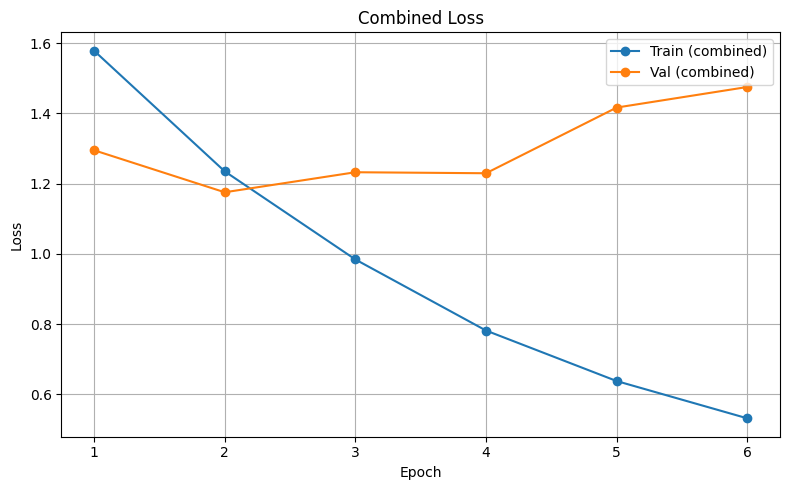

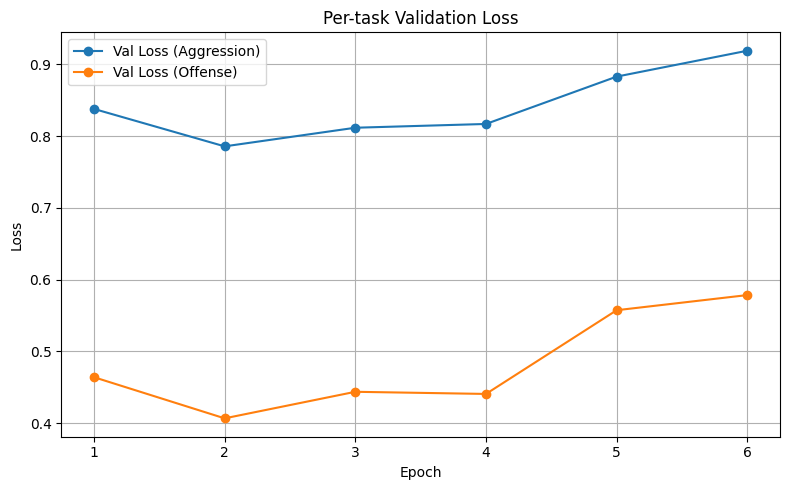

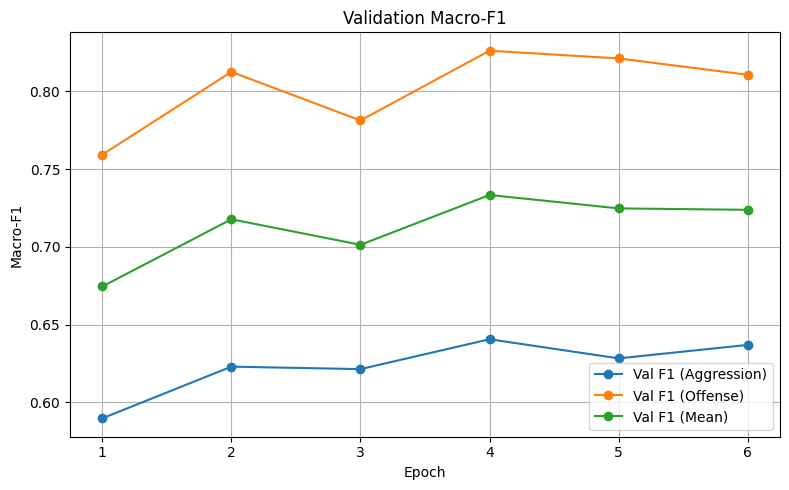

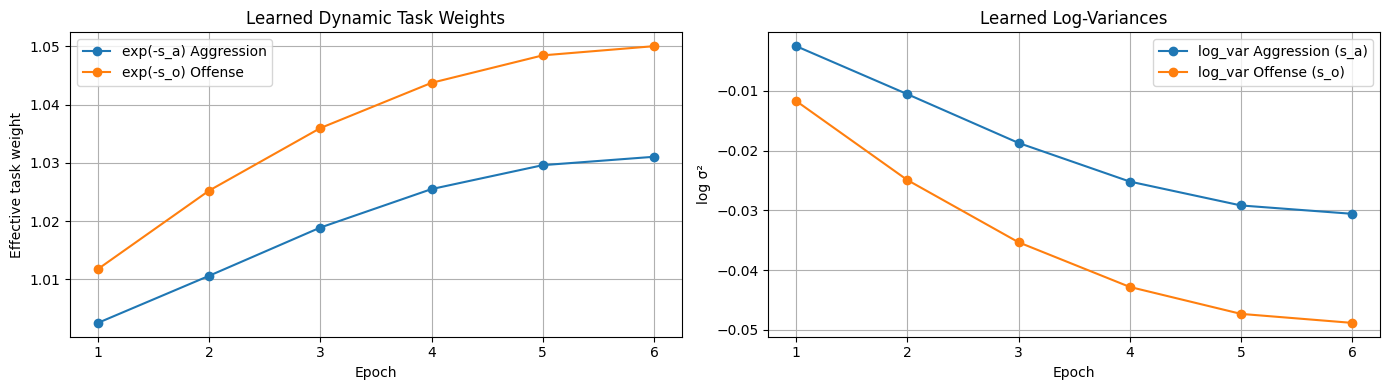

In [20]:
epochs = range(1, len(history["train_loss"]) + 1)

# Loss curves
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train (combined)")
plt.plot(epochs, history["val_loss"],   marker="o", label="Val (combined)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Combined Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Per-task validation loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_loss_a"], marker="o", label="Val Loss (Aggression)")
plt.plot(epochs, history["val_loss_o"], marker="o", label="Val Loss (Offense)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Per-task Validation Loss")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Macro-F1
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["val_macro_f1_aggression"], marker="o", label="Val F1 (Aggression)")
plt.plot(epochs, history["val_macro_f1_offense"],    marker="o", label="Val F1 (Offense)")
plt.plot(epochs, history["val_macro_f1_mean"],       marker="o", label="Val F1 (Mean)")
plt.xlabel("Epoch"); plt.ylabel("Macro-F1"); plt.title("Validation Macro-F1")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Dynamic task weights
if CFG.use_dynamic_weighting:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(epochs, history["task_weight_a"], marker="o", label="exp(-s_a) Aggression")
    axes[0].plot(epochs, history["task_weight_o"], marker="o", label="exp(-s_o) Offense")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Effective task weight")
    axes[0].set_title("Learned Dynamic Task Weights")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history["log_var_a"], marker="o", label="log_var Aggression (s_a)")
    axes[1].plot(epochs, history["log_var_o"], marker="o", label="log_var Offense (s_o)")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("log σ²")
    axes[1].set_title("Learned Log-Variances")
    axes[1].legend(); axes[1].grid(True)
    plt.tight_layout(); plt.show()
else:
    print("Dynamic weighting disabled — using fixed w_a = {:.3f}".format(CFG.w_a))

## 23. Improvement 4a — Confusion matrices

Heatmaps for each task. Rows = ground truth, columns = predicted. Computed on the **test set**.

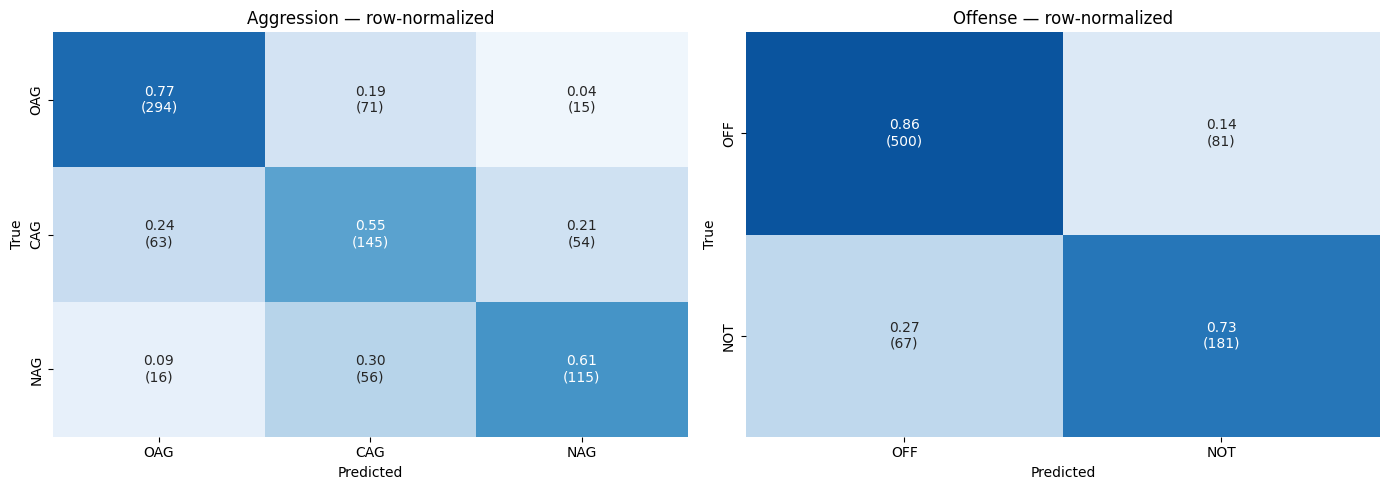

In [21]:
def plot_confusion(cm, labels, title, ax, normalize=True):
    if normalize:
        cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        annot_data = np.array([[f"{cm_norm[i,j]:.2f}\n({cm[i,j]})"
                                for j in range(cm.shape[1])]
                               for i in range(cm.shape[0])])
        sns.heatmap(cm_norm, annot=annot_data, fmt="", cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax, cbar=False,
                    vmin=0.0, vmax=1.0)
    else:
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)


cm_a = confusion_matrix(test_results["labels_a"], test_results["preds_a"], labels=[0, 1, 2])
cm_o = confusion_matrix(test_results["labels_o"], test_results["preds_o"], labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion(cm_a, ["OAG", "CAG", "NAG"], "Aggression — row-normalized", axes[0])
plot_confusion(cm_o, ["OFF", "NOT"],        "Offense — row-normalized",    axes[1])
plt.tight_layout(); plt.show()

## 24. Improvement 4b — Joint cross-task error analysis

The two tasks are correlated. The 2 × 3 joint confusion below cross-tabulates true offense (rows: OFF/NOT) against true aggression (columns: OAG/CAG/NAG) **for prediction errors only** — separately for each task. This makes it easy to see, e.g., whether OFF examples mostly fail on the OAG class.

In [22]:
# True joint distribution of (offense, aggression) on test
test_df_eval = test_df.reset_index(drop=True).copy()
test_df_eval["pred_a"] = test_results["preds_a"]
test_df_eval["pred_o"] = test_results["preds_o"]
test_df_eval["err_a"] = test_df_eval["aggression"] != test_df_eval["pred_a"]
test_df_eval["err_o"] = test_df_eval["offense"]    != test_df_eval["pred_o"]

# 2 (offense) x 3 (aggression) joint distribution overall
joint = pd.crosstab(
    test_df_eval["offense"].map(INV_OFF),
    test_df_eval["aggression"].map(INV_AGG),
    margins=True, margins_name="Total",
)
print("Joint distribution of true labels (rows = offense, cols = aggression):")
print(joint)

# Aggression error rate within each (offense, aggression) cell
print("\nAggression error rate within each (true offense × true aggression) cell:")
agg_err_rate = (test_df_eval
                .groupby([test_df_eval["offense"].map(INV_OFF),
                          test_df_eval["aggression"].map(INV_AGG)])["err_a"]
                .mean()
                .unstack()
                .round(3))
print(agg_err_rate)

# Offense error rate within each cell
print("\nOffense error rate within each (true offense × true aggression) cell:")
off_err_rate = (test_df_eval
                .groupby([test_df_eval["offense"].map(INV_OFF),
                          test_df_eval["aggression"].map(INV_AGG)])["err_o"]
                .mean()
                .unstack()
                .round(3))
print(off_err_rate)

Joint distribution of true labels (rows = offense, cols = aggression):
aggression  CAG  NAG  OAG  Total
offense                         
NOT          83  132   33    248
OFF         179   55  347    581
Total       262  187  380    829

Aggression error rate within each (true offense × true aggression) cell:
aggression    CAG    NAG    OAG
offense                        
NOT         0.398  0.280  0.364
OFF         0.469  0.636  0.213

Offense error rate within each (true offense × true aggression) cell:
aggression    CAG    NAG    OAG
offense                        
NOT         0.229  0.303  0.242
OFF         0.240  0.291  0.063


## 25. Improvement 4c — Top misclassified examples

Highest-confidence errors are the most informative for debugging because they reflect where the model is *confidently wrong* rather than just unsure.

In [23]:
def top_confident_errors(df, probs, true_col, pred_col, inv_map, k=10):
    """Return the top-k highest-confidence wrong predictions."""
    conf = probs.max(axis=1)
    df = df.copy()
    df["confidence"] = conf
    df["true_label"] = df[true_col].map(inv_map)
    df["pred_label"] = df[pred_col].map(inv_map)
    wrong = df[df[true_col] != df[pred_col]]
    return wrong.nlargest(k, "confidence")[["tweet", "true_label", "pred_label", "confidence"]]


print("=" * 80)
print("Top 10 highest-confidence AGGRESSION errors")
print("=" * 80)
agg_errors = top_confident_errors(
    test_df_eval, test_results["probs_a"],
    true_col="aggression", pred_col="pred_a", inv_map=INV_AGG, k=10,
)
for _, row in agg_errors.iterrows():
    print(f"[true={row['true_label']:>3} | pred={row['pred_label']:>3} | conf={row['confidence']:.3f}] {row['tweet'][:160]}")

print()
print("=" * 80)
print("Top 10 highest-confidence OFFENSE errors")
print("=" * 80)
off_errors = top_confident_errors(
    test_df_eval, test_results["probs_o"],
    true_col="offense", pred_col="pred_o", inv_map=INV_OFF, k=10,
)
for _, row in off_errors.iterrows():
    print(f"[true={row['true_label']:>3} | pred={row['pred_label']:>3} | conf={row['confidence']:.3f}] {row['tweet'][:160]}")

Top 10 highest-confidence AGGRESSION errors
[true=CAG | pred=OAG | conf=0.991] Tector (Barbados Royals), Little (Pretoria Capitals) and Stirling (Abu Dhabi KR) have been picked by teams owned by IPL franchise owners. 

This tells me that t
[true=CAG | pred=OAG | conf=0.986] Of course like with anything , this is not meant as a generalisation per say- but a means of asking why. To have a council with a room packed with Muslim studen
[true=CAG | pred=OAG | conf=0.985] Are you sure that VIP undertrials are treated in similar way? I don’t think so.
[true=CAG | pred=OAG | conf=0.981] i’ll be back every 2-4 months to remind all of u that i have her btw
[true=CAG | pred=OAG | conf=0.966] Louis Federal Reserve found that government spending has little to no impact on inflation. In fact, a 10% increase in government spending may lead to a 0.08% de
[true=CAG | pred=OAG | conf=0.965] "Peak secularism" as @user puts it.
[true=CAG | pred=NAG | conf=0.960] By the way , Indira Gandhi was a Muslim , h

## 26. Improvement 4d — Token saliency maps

Per-token attribution computed as `|gradient × input|` on the word embeddings (a.k.a. **gradient × input saliency**, Shrikumar et al. 2017). For each example we:
1. Pull out the input embeddings.  
2. Forward through the full model and pick the logit for the predicted class.  
3. Backprop that scalar to the input embeddings.  
4. Use the L1 norm over the hidden dim as the per-token attribution score.  
5. Render with HTML, with darker red ⇒ more influential.

This works for either task and respects the hierarchy flag — when `use_hierarchy=True`, the aggression saliency reflects the full hierarchical computation.

In [24]:
from IPython.display import HTML, display

def compute_token_saliency(
    model: MTTLModel,
    tokenizer,
    text: str,
    task: str = "aggression",          # "aggression" | "offense"
    target_class: Optional[int] = None,
    device: torch.device = DEVICE,
    max_length: int = 128,
):
    """Return (tokens, saliency, target_class, predicted_class)."""
    assert task in ("aggression", "offense")

    model.eval()
    text = normalize_tweet(text)
    enc = tokenizer(
        text, truncation=True, max_length=max_length,
        padding=True, return_tensors="pt",
    )
    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    # Get word embeddings and enable gradients on them
    embed_layer = model.encoder.get_input_embeddings()
    embeds = embed_layer(input_ids).detach().clone()
    embeds.requires_grad_(True)

    outputs = model(inputs_embeds=embeds, attention_mask=attention_mask)
    logits = outputs.logits_a if task == "aggression" else outputs.logits_o
    probs = F.softmax(logits, dim=-1)
    pred_class = int(probs.argmax(dim=-1).item())
    if target_class is None:
        target_class = pred_class

    score = logits[0, target_class]
    model.zero_grad(set_to_none=True)
    score.backward()

    # gradient × input, L1 over hidden
    grad = embeds.grad.detach()                                # [1, T, H]
    sal = (grad * embeds.detach()).abs().sum(dim=-1).squeeze(0)  # [T]

    # Mask out padding
    mask = attention_mask.squeeze(0).float()
    sal = sal * mask
    if sal.max() > 0:
        sal = sal / sal.max()

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    return tokens, sal.cpu().numpy(), target_class, pred_class


def render_saliency_html(tokens, sal, title=""):
    """Render tokens with red highlights proportional to saliency."""
    pieces = [f"<div style='font-family:monospace;line-height:2.0'><b>{title}</b><br>"]
    for tok, s in zip(tokens, sal):
        # Skip special tokens for cleaner display, but keep them muted
        if tok in (tokenizer.cls_token, tokenizer.sep_token, tokenizer.pad_token):
            display_tok = tok.replace("<", "&lt;").replace(">", "&gt;")
            pieces.append(f"<span style='color:#999;margin:0 2px'>{display_tok}</span>")
            continue
        # Background red intensity
        alpha = float(np.clip(s, 0.0, 1.0))
        bg = f"rgba(220, 50, 50, {alpha:.2f})"
        # Text color stays readable
        display_tok = tok.replace("<", "&lt;").replace(">", "&gt;").replace("Ġ", "·")
        pieces.append(
            f"<span style='background:{bg};padding:2px 4px;margin:0 1px;border-radius:3px'>{display_tok}</span>"
        )
    pieces.append("</div>")
    return "".join(pieces)


# Pick a few interesting examples: the highest-confidence correct + a couple of errors
def visualize_saliency_for_examples(examples, df, probs, true_col, pred_col, inv_map, task):
    """examples: iterable of row indices into df."""
    for idx in examples:
        row = df.iloc[idx]
        text = str(row["tweet"])
        true_lbl = inv_map[int(row[true_col])]
        pred_lbl = inv_map[int(row[pred_col])]
        conf = float(probs[idx].max())
        tokens, sal, target_class, pred_class = compute_token_saliency(
            best_model, tokenizer, text, task=task,
        )
        title = (f"[{task.upper()}] true={true_lbl} | pred={pred_lbl} | "
                 f"conf={conf:.3f} | tweet idx={idx}")
        display(HTML(render_saliency_html(tokens, sal, title=title)))


# 1) A couple of high-confidence correct AGGRESSION predictions
correct_a = test_df_eval[~test_df_eval["err_a"]].copy()
correct_a["conf"] = test_results["probs_a"][correct_a.index].max(axis=1)
top_correct_a_idx = correct_a.nlargest(2, "conf").index.tolist()

# 2) A couple of high-confidence WRONG aggression predictions
wrong_a = test_df_eval[test_df_eval["err_a"]].copy()
wrong_a["conf"] = test_results["probs_a"][wrong_a.index].max(axis=1)
top_wrong_a_idx = wrong_a.nlargest(2, "conf").index.tolist()

# 3) Same for OFFENSE
correct_o = test_df_eval[~test_df_eval["err_o"]].copy()
correct_o["conf"] = test_results["probs_o"][correct_o.index].max(axis=1)
top_correct_o_idx = correct_o.nlargest(2, "conf").index.tolist()

wrong_o = test_df_eval[test_df_eval["err_o"]].copy()
wrong_o["conf"] = test_results["probs_o"][wrong_o.index].max(axis=1)
top_wrong_o_idx = wrong_o.nlargest(2, "conf").index.tolist()

display(HTML("<h3>Aggression saliency — confident correct</h3>"))
visualize_saliency_for_examples(top_correct_a_idx, test_df_eval, test_results["probs_a"],
                                "aggression", "pred_a", INV_AGG, "aggression")

display(HTML("<h3>Aggression saliency — confident errors</h3>"))
if top_wrong_a_idx:
    visualize_saliency_for_examples(top_wrong_a_idx, test_df_eval, test_results["probs_a"],
                                    "aggression", "pred_a", INV_AGG, "aggression")
else:
    print("No aggression errors found.")

display(HTML("<h3>Offense saliency — confident correct</h3>"))
visualize_saliency_for_examples(top_correct_o_idx, test_df_eval, test_results["probs_o"],
                                "offense", "pred_o", INV_OFF, "offense")

display(HTML("<h3>Offense saliency — confident errors</h3>"))
if top_wrong_o_idx:
    visualize_saliency_for_examples(top_wrong_o_idx, test_df_eval, test_results["probs_o"],
                                    "offense", "pred_o", INV_OFF, "offense")
else:
    print("No offense errors found.")

## 27. Inference helper for new text

In [25]:
def predict_text(model, text: str, show_saliency: bool = False):
    model.eval()
    text = normalize_tweet(text)
    enc = tokenizer(
        text, truncation=True, max_length=CFG.max_length,
        padding=True, return_tensors="pt",
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}

    with torch.no_grad():
        outputs = model(**enc)

    probs_a = torch.softmax(outputs.logits_a, dim=-1).cpu().numpy()[0]
    probs_o = torch.softmax(outputs.logits_o, dim=-1).cpu().numpy()[0]
    pred_a = int(np.argmax(probs_a))
    pred_o = int(np.argmax(probs_o))

    result = {
        "text": text,
        "aggression_pred_id": pred_a,
        "aggression_pred_label": INV_AGG.get(pred_a, str(pred_a)),
        "aggression_probs": {INV_AGG[i]: float(probs_a[i]) for i in range(len(probs_a))},
        "offense_pred_id": pred_o,
        "offense_pred_label": INV_OFF.get(pred_o, str(pred_o)),
        "offense_probs": {INV_OFF[i]: float(probs_o[i]) for i in range(len(probs_o))},
    }

    if show_saliency:
        for task in ("aggression", "offense"):
            tokens, sal, _, _ = compute_token_saliency(model, tokenizer, text, task=task)
            display(HTML(render_saliency_html(
                tokens, sal,
                title=f"{task} saliency: pred = {result[f'{task}_pred_label']}",
            )))

    return result


example = predict_text(best_model, "@someone tum bohat bakwas kar rahe ho", show_saliency=True)
example

{'text': '@user tum bohat bakwas kar rahe ho',
 'aggression_pred_id': 0,
 'aggression_pred_label': 'OAG',
 'aggression_probs': {'OAG': 0.549206018447876,
  'CAG': 0.3741813600063324,
  'NAG': 0.07661261409521103},
 'offense_pred_id': 0,
 'offense_pred_label': 'OFF',
 'offense_probs': {'OFF': 0.7502877712249756, 'NOT': 0.249712273478508}}

## 28. Save tokenizer and training history

In [26]:
tokenizer.save_pretrained(CFG.output_dir)

with open(os.path.join(CFG.output_dir, "history.json"), "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

# Also dump the final config so the output folder is self-describing
final_cfg = {
    k: v for k, v in vars(CFG).items()
    if not k.startswith("_") and not callable(v)
}
with open(os.path.join(CFG.output_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump(final_cfg, f, indent=2)

print("Saved artifacts to:", CFG.output_dir)
print("Files:", sorted(os.listdir(CFG.output_dir)))

Saved artifacts to: ./mttl_improved_outputs
Files: ['best_model.pt', 'config.json', 'history.json', 'tokenizer.json', 'tokenizer_config.json']


## 29. Notes

### Disabling improvement 3 only
If hierarchical prediction hurts results on your split, set `CFG.use_hierarchy = False` at the top of the notebook and re-run. Improvements 1, 2, and 4 will still apply unchanged.

### Disabling improvements individually
- **Improvement 1 (dynamic weighting)**: set `CFG.use_dynamic_weighting = False`. The fixed `CFG.w_a = 0.4` mixture is used as a fallback.
- **Improvement 2 (focal loss)**: set `CFG.loss_type = "ce"`. Reverts to weighted cross-entropy with `gamma = 0`.
- **Improvement 3 (hierarchy)**: set `CFG.use_hierarchy = False`.
- **Improvement 4 (error analysis)**: just skip cells 23–26.

### Reproducibility
All seeds (`random`, `numpy`, `torch`, `torch.cuda`) are set to `46`. Results may still vary slightly across hardware due to CUDA non-determinism in some kernels.